In [2]:
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = sio.loadmat('ES_Q2.mat')

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'A_day1', 'A_day2', 'A_day3', 'B_day1', 'B_day2', 'B_day3', 'C_day1', 'C_day2', 'C_day3', 'D_day1', 'D_day2', 'D_day3'])


In [4]:
A1 = data['A_day1']
B1 = data['B_day1']
C1 = data['C_day1']
D1 = data['D_day1']

A2 = data['A_day2']
B2 = data['B_day2']
C2 = data['C_day2']
D2 = data['D_day2']

A3 = data['A_day3']
B3 = data['B_day3']
C3 = data['C_day3']
D3 = data['D_day3']

In [5]:
fs = 100
dt = 1/fs

def modal_parameters(A, C, dt):
    
    eigvals, eigvecs = np.linalg.eig(A)
    
    # Continuous poles
    s = np.log(eigvals)/dt
    
    # Keep only positive imaginary poles
    idx = np.where(np.imag(s) > 0)[0]
    
    s_sel   = s[idx]
    phi_sel = eigvecs[:, idx]
    
    freq = []
    zeta = []
    shapes = []
    
    for j in range(len(idx)):
        
        sj = s_sel[j]
        phij = phi_sel[:,j]
        
        wn = np.abs(sj)
        fj = wn/(2*np.pi)
        zj = -np.real(sj)/wn
        
        psi = C @ phij
        
        # phase correction
        k = np.argmax(np.abs(psi))
        theta = -np.angle(psi[k])
        
        v = np.real(psi*np.exp(1j*theta))
        v = v/np.max(np.abs(v))
        
        freq.append(fj)
        zeta.append(zj)
        shapes.append(v)
    
    freq = np.array(freq)
    zeta = np.array(zeta)
    shapes = np.array(shapes).T
    
    # sort ascending frequency
    idxs = np.argsort(freq)
    
    freq = freq[idxs]
    zeta = zeta[idxs]
    shapes = shapes[:,idxs]
    
    return freq, zeta, shapes

In [6]:
f1, z1, phi1 = modal_parameters(A1, C1, dt)
f2, z2, phi2 = modal_parameters(A2, C2, dt)
f3, z3, phi3 = modal_parameters(A3, C3, dt)

print("Day 1 Frequencies =", f1)
print("Day 1 Damping =", z1)

print("Day 2 Frequencies =", f2)
print("Day 2 Damping =", z2)

print("Day 3 Frequencies =", f3)
print("Day 3 Damping =", z3)

Day 1 Frequencies = [0.31105164 0.81434376]
Day 1 Damping = [0.05 0.05]
Day 2 Frequencies = [0.31105164 0.81434376]
Day 2 Damping = [0.05 0.05]
Day 3 Frequencies = [0.27240388 0.65752454]
Day 3 Damping = [0.05947147 0.06093995]


In [7]:
def MAC(u,v):
    u = u.reshape(-1,1)
    v = v.reshape(-1,1)
    
    num = np.abs(u.T @ v)**2
    den = (u.T @ u)*(v.T @ v)
    
    return float(num/den)

In [8]:
results = []

for i in range(len(f1)):
    
    # Day 2
    err_f2 = (f2[i]-f1[i])/f1[i]*100
    err_z2 = (z2[i]-z1[i])/z1[i]*100
    mac2   = MAC(phi1[:,i], phi2[:,i])
    
    # Day 3
    err_f3 = (f3[i]-f1[i])/f1[i]*100
    err_z3 = (z3[i]-z1[i])/z1[i]*100
    mac3   = MAC(phi1[:,i], phi3[:,i])
    
    results.append([
        i+1,
        f1[i], f2[i], f3[i],
        err_f2, err_f3,
        mac2, mac3
    ])

C:\Users\Kushagra\AppData\Local\Temp\ipykernel_41772\1270466965.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(num/den)


In [9]:
df = pd.DataFrame(results, columns=[
    'Mode',
    'Day1 f',
    'Day2 f',
    'Day3 f',
    '%Δf Day2',
    '%Δf Day3',
    'MAC Day2',
    'MAC Day3'
])

df

,Mode,Day1 f,Day2 f,Day3 f,%Δf Day2,%Δf Day3,MAC Day2,MAC Day3
0,1,0.311052,0.311052,0.272404,2.148692e-11,-12.424867,1.0,0.974292
1,2,0.814344,0.814344,0.657525,5.317005e-11,-19.257127,1.0,0.974437


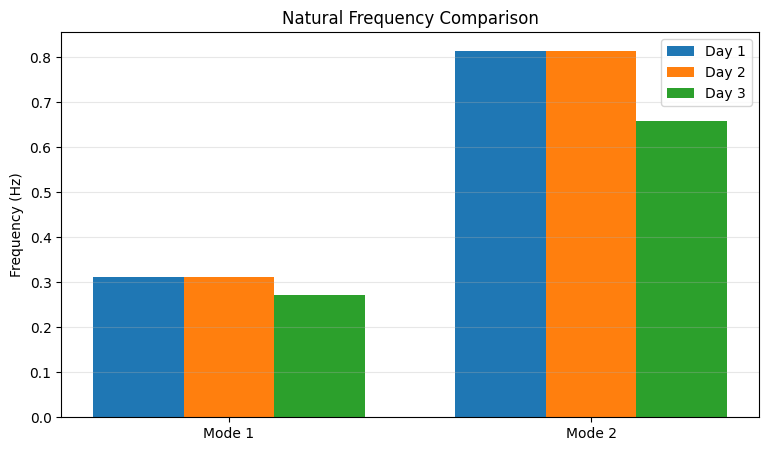

In [10]:
modes = ['Mode 1', 'Mode 2']
x = np.arange(len(modes))
w = 0.25

plt.figure(figsize=(9,5))

plt.bar(x-w, f1, width=w, label='Day 1')
plt.bar(x,   f2, width=w, label='Day 2')
plt.bar(x+w, f3, width=w, label='Day 3')

plt.xticks(x, modes)
plt.ylabel('Frequency (Hz)')
plt.title('Natural Frequency Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Treating Day 1 as the healthy reference state, Day 2 can be considered healthy since the natural frequencies remain unchanged and the MAC values are equal to 1, indicating identical modal properties. 

However, Day 3 shows significant reductions in both modal frequencies (12.4% and 19.3%), indicating a change in structural dynamic characteristics. 

Therefore, the building is healthy on Day 2 but damaged on Day 3.